# Statistics & EDA Lab: Understanding Your Data Before Modeling

## Student Practice Notebook

**Name:** Divya Saxena
**Register Number:** AP24110011570
**Date:** 30-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute and interpret descriptive statistics beyond `.describe()` (variance, std, skewness)
- Visualize and identify distribution shapes (normal vs skewed)
- Compute and interpret correlation between features
- Run a basic hypothesis test (t-test) and interpret a p-value
- Understand confidence intervals conceptually
- Apply statistical thinking to image and text data

### Why this week matters
You now have clean, scaled, encoded data. Before building any model, a good data scientist asks: **what does this data actually look like? Which features seem related? Is a difference I'm seeing real, or just noise?** That's what statistics answers.

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Descriptive Statistics Beyond `.describe()`

`.describe()` gives mean, std, min/max, quartiles. Two more measures matter a lot for understanding data shape:

- **Variance / Std Dev**: how spread out the data is
- **Skewness**: whether the data leans left (negative skew) or right (positive skew), or is symmetric (skew ≈ 0)

### Demonstration


In [ ]:
print("Mean:", tips['total_bill'].mean())
print("Median:", tips['total_bill'].median())
print("Variance:", tips['total_bill'].var())
print("Std Dev:", tips['total_bill'].std())
print("Skewness:", tips['total_bill'].skew())

Mean: 19.78594262295082
Median: 17.795
Variance: 79.25293861397827
Std Dev: 8.902411954856856
Skewness: 1.1332130376158205


**Reading skewness:**
- Skew ≈ 0 → roughly symmetric
- Skew > 0 → right-skewed (long tail of high values; mean > median)
- Skew < 0 → left-skewed (long tail of low values; mean < median)


### Student Practice

Compute mean, median, variance, std dev, and skewness for the `tip_pct` column. Based on the mean vs median relationship, is it left-skewed, right-skewed, or roughly symmetric? Write your conclusion.


In [9]:
# Write your answer here
print("Mean:", tips['tip_pct'].mean())
print("Median:", tips['tip_pct'].median())
print("Variance:", tips['tip_pct'].var())
print("Std Dev:", tips['tip_pct'].std())
print("Skewness:", tips['tip_pct'].skew())

Mean: 0.16080258172250472
Median: 0.15476977125802577
Variance: 0.0037298141248170553
Std Dev: 0.06107220419157192
Skewness: 3.3492170245653594


**Reflection:** Why can two columns have the *same mean* but very different std dev / skewness? Why does this matter when deciding how to preprocess a feature (recall Week 3 scaling/outliers)?

*Your answer:*

Two columns can have the same mean but different spread and distribution. One may have a large std dev or strong skewness, while the other may be more evenly distributed. This matters because features with different spread or outliers may need scaling or outlier treatment before building an ML model.


## Part 2: Visualizing Distributions

Numbers alone can be misleading — always look at the shape too.

### Demonstration


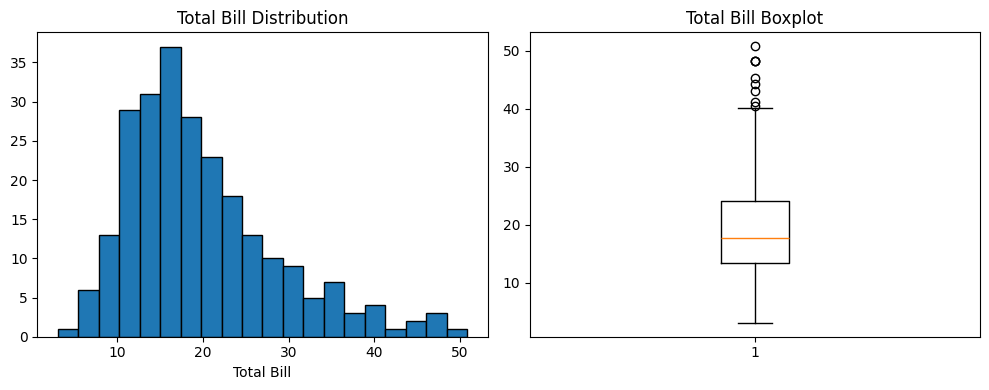

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].hist(tips['total_bill'], bins=20, edgecolor='black')
axes[0].set_title("Total Bill Distribution")
axes[0].set_xlabel("Total Bill")

axes[1].boxplot(tips['total_bill'])
axes[1].set_title("Total Bill Boxplot")

plt.tight_layout()
plt.show()


### Student Practice — predict then check

Predict: will `tip_pct`'s histogram look more symmetric (bell-shaped) or skewed, based on your Part 1 answer? Write your prediction, then plot a histogram and boxplot for `tip_pct` to check.

*Your prediction:*


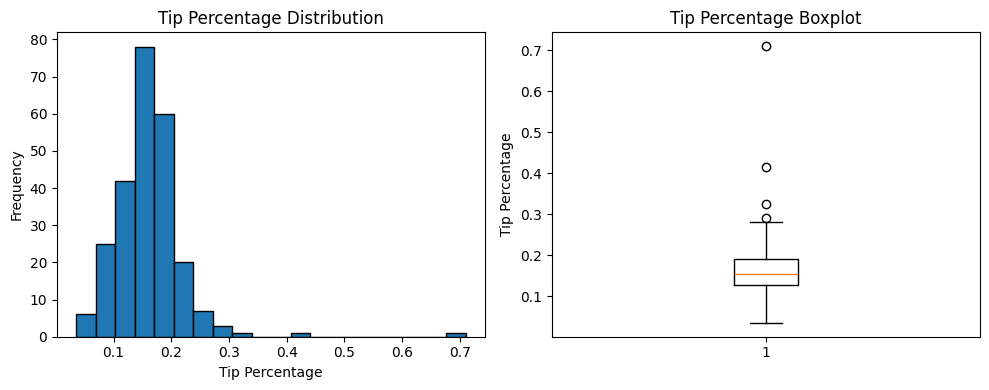

In [10]:
# Write your answer here
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(tips['tip_pct'], bins=20, edgecolor='black')
axes[0].set_title("Tip Percentage Distribution")
axes[0].set_xlabel("Tip Percentage")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(tips['tip_pct'])
axes[1].set_title("Tip Percentage Boxplot")
axes[1].set_ylabel("Tip Percentage")

plt.tight_layout()
plt.show()

## Part 3: Correlation

Correlation measures how strongly two numeric variables move together, from -1 (perfectly inverse) to +1 (perfectly aligned). 0 means no linear relationship.

### Demonstration


Correlation between total_bill and tip: 0.676


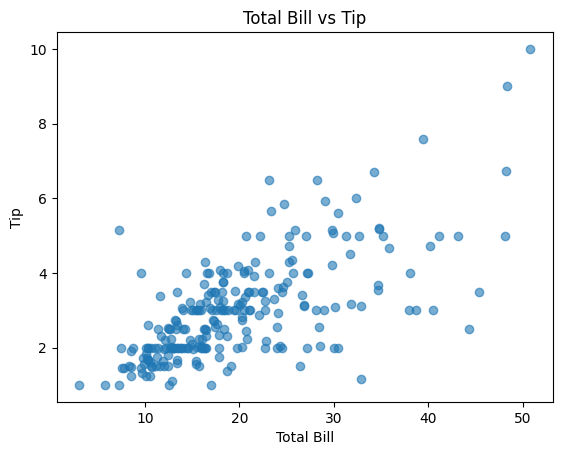

In [4]:
correlation = tips['total_bill'].corr(tips['tip'])
print(f"Correlation between total_bill and tip: {correlation:.3f}")

plt.figure()
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


In [6]:
# Correlation matrix across all numeric columns
numeric_cols = tips.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
corr_matrix


,total_bill,tip,size,tip_pct
total_bill,1.000,0.676,0.598,-0.339
tip,0.676,1.000,0.489,0.342
size,0.598,0.489,1.000,-0.143
tip_pct,-0.339,0.342,-0.143,1.000


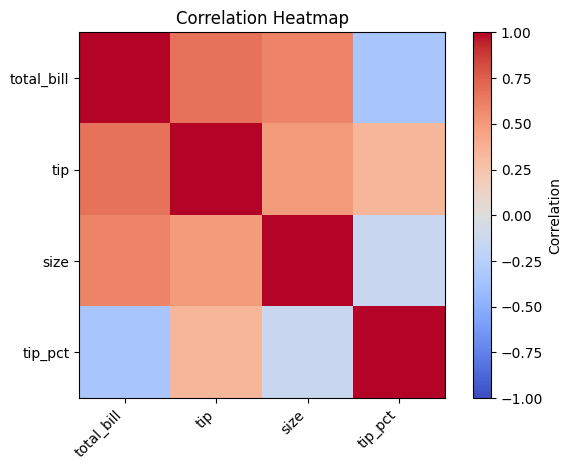

In [7]:
# Visualize as a heatmap
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Student Practice

1. What is the correlation between `size` (party size) and `total_bill`? Is it weak, moderate, or strong?
2. What is the correlation between `size` and `tip_pct`? Compare this to `size` vs `total_bill` — which relationship is stronger, and does that surprise you?


In [32]:
# Write your answer here

# 1. `size` vs `total_bill` = **0.598**, which is a **moderate positive correlation**. Larger parties generally have higher total bills.

# 2. `size` vs `tip_pct` = **-0.143**, which is a **weak negative correlation**. The `size` vs `total_bill` relationship is much stronger. This is not surprising because larger groups usually have higher bills, but their tip percentage does not necessarily increase.



**Reflection:** Correlation measures a *linear* relationship. Can two variables be strongly related but have a correlation near 0? Explain how that's possible (hint: think about non-linear/curved relationships).

*Your answer:*

Yes. Two variables can be strongly related but have a correlation near 0 if their relationship is non-linear. For example, a U-shaped or curved relationship can be strong, but because correlation only measures linear relationships, the positive and negative parts can cancel each other out and produce a correlation close to 0.



## Part 4: Hypothesis Testing — Is a Difference Real?

You've seen group averages differ (e.g. average tip_pct by day). But is that difference **statistically significant**, or could it just be random variation? A **t-test** compares two group means and gives a **p-value**: the probability of seeing a difference this large (or larger) if there were truly no difference.

**Rule of thumb:** if p-value < 0.05, we consider the difference statistically significant.

### Demonstration: do smokers tip a different percentage than non-smokers?


In [8]:
smoker_tips = tips[tips['smoker']=='Yes']['tip_pct']
nonsmoker_tips = tips[tips['smoker']=='No']['tip_pct']

print("Smoker mean tip_pct:", smoker_tips.mean())
print("Non-smoker mean tip_pct:", nonsmoker_tips.mean())

t_stat, p_value = stats.ttest_ind(smoker_tips, nonsmoker_tips)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference (could be random variation)")

Smoker mean tip_pct: 0.16319604463687792
Non-smoker mean tip_pct: 0.15932846217921523

t-statistic: 0.480
p-value: 0.632
Result: NOT a statistically significant difference (could be random variation)


### Student Practice — predict then check

Predict: do you think there's a statistically significant difference in `tip_pct` between Lunch and Dinner? Write your prediction and reasoning, then run a t-test to check.

*Your prediction:*


In [ ]:
# Write your answer here

# I predict there will be a statistically significant difference in `tip_pct` between Lunch and Dinner because tipping patterns may differ between the two meal times.


**Reflection:** Why is it important to check statistical significance instead of just comparing two mean values directly and assuming any difference is meaningful?

*Your answer:*

 Statistical significance helps determine whether the difference between two means is likely to be a real difference or just due to random variation. A small difference in means does not necessarily mean the groups are truly different.


## Part 5: Confidence Intervals (Conceptual Introduction)

A **confidence interval (CI)** gives a range where we're reasonably confident the true population mean lies, based on our sample. A 95% CI means: if we repeated this sampling process many times, about 95% of such intervals would contain the true mean.

### Demonstration


In [29]:
mean_bill = tips['total_bill'].mean()
sem = stats.sem(tips['total_bill'])  # standard error of the mean
ci = stats.t.interval(0.95, len(tips)-1, loc=mean_bill, scale=sem)

print(f"Sample mean total_bill: {mean_bill:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")


Sample mean total_bill: 19.79
95% Confidence Interval: (18.66, 20.91)


### Student Practice

Compute the 95% confidence interval for `tip_pct`. In one sentence, explain what this interval tells you (in plain language, not just formula terms).


In [13]:
# Write your answer here


mean_tip_pct = tips['tip_pct'].mean()
sem = stats.sem(tips['tip_pct'])

ci = stats.t.interval(0.95, len(tips)-1, loc=mean_tip_pct, scale=sem)

print(f"Sample mean tip_pct: {mean_tip_pct:.3f}")
print(f"95% Confidence Interval: ({ci[0]:.3f}, {ci[1]:.3f})")

# Conclusion: We are 95% confident that the true average tip percentage is between the lower and upper confidence interval values.


Sample mean tip_pct: 0.161
95% Confidence Interval: (0.153, 0.169)


# Mini Project A: Statistical Comparison of Images (Image Track)

Using the image metadata DataFrame you built in Week 2 (filename, brightness, RGB averages, etc.), apply statistical thinking to compare your images.

## Step 1: Rebuild your image metadata table


In [18]:
from PIL import Image
import numpy as np
import pandas as pd

img = Image.open("img.jpg").convert("RGB")
arr = np.array(img)

brightness = arr.mean()
R_avg = arr[:, :, 0].mean()
G_avg = arr[:, :, 1].mean()
B_avg = arr[:, :, 2].mean()

image_df = pd.DataFrame([{
    "filename": "img.png",
    "brightness": brightness,
    "R_avg": R_avg,
    "G_avg": G_avg,
    "B_avg": B_avg
}])

print(image_df)

  filename  brightness    R_avg    G_avg    B_avg
0  img.png     132.068  144.647  102.394  149.161


In [21]:
from PIL import Image
import numpy as np
import pandas as pd

filename = "img.jpg"

arr = np.array(Image.open(filename).convert("RGB"))

image_df = pd.DataFrame([{
    'filename': filename,
    'avg_brightness': np.mean(arr),
    'avg_red': np.mean(arr[:, :, 0]),
    'avg_green': np.mean(arr[:, :, 1]),
    'avg_blue': np.mean(arr[:, :, 2]),
    'height': arr.shape[0],
    'width': arr.shape[1]
}])

print(image_df)

  filename  avg_brightness  avg_red  avg_green  avg_blue  height  width
0  img.jpg         132.068  144.647    102.394   149.161    1265   1066


## Step 2: Statistical analysis

1. Compute the mean, std dev, and skewness of `avg_brightness` across your images.
2. Compute the correlation between `avg_brightness` and `avg_red` (do brighter images tend to have more red?).
3. **If you have at least 2 images you can meaningfully group** (e.g. indoor vs outdoor, or any 2 categories you choose), run a t-test comparing their `avg_brightness`. If you only have very few images, skip the t-test and instead just discuss whether a t-test would even be reliable with so few samples.


In [22]:
# Write your answer here
from scipy import stats

# 1. Mean, standard deviation, and skewness
mean_brightness = image_df['avg_brightness'].mean()
std_brightness = image_df['avg_brightness'].std()
skew_brightness = image_df['avg_brightness'].skew()

print("Mean brightness:", mean_brightness)
print("Std Dev brightness:", std_brightness)
print("Skewness brightness:", skew_brightness)

# 2. Correlation between brightness and red
correlation = image_df['avg_brightness'].corr(image_df['avg_red'])

print("Correlation between brightness and red:", correlation)

Mean brightness: 132.06759610131826
Std Dev brightness: nan
Skewness brightness: nan
Correlation between brightness and red: nan


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


**Reflection:** With only 3-5 images, can you trust statistical significance results (like a t-test p-value) the same way you would with 200+ rows like the tips dataset? Why or why not?

*Your answer:*

No, with only 3–5 images, statistical significance results are less reliable because the sample size is too small. With 200+ observations, the results are more stable and provide stronger evidence for conclusions.

# Mini Project B: Word Frequency Distribution Analysis (NLP Track)

## Step 1: Build a word frequency table for a longer text

### Demonstration: Zipf's Law preview

A famous finding in linguistics: in most natural language text, word frequency is **highly right-skewed** — a few words (like "the", "a") appear extremely often, and most words appear only once or twice. This is called **Zipf's Law**.


In [23]:
paragraph = (
    "Data science combines statistics and programming. Statistics helps us understand data. "
    "Programming helps us process data. Machine learning is a part of data science. "
    "Data science uses statistics, programming, and machine learning together. "
    "Understanding statistics is essential for data science."
)

tokens = paragraph.lower().replace('.', '').replace(',', '').split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts}).sort_values('count', ascending=False).reset_index(drop=True)
print(word_freq)
print("\nSkewness of word counts:", word_freq['count'].skew())


             word  count
0            data      6
1         science      4
2      statistics      4
3     programming      3
4              us      2
5           helps      2
6              is      2
7        learning      2
8         machine      2
9             and      2
10              a      1
11  understanding      1
12     understand      1
13       together      1
14             of      1
15        process      1
16           part      1
17            for      1
18      essential      1
19       combines      1
20           uses      1

Skewness of word counts: 1.8510785401434868


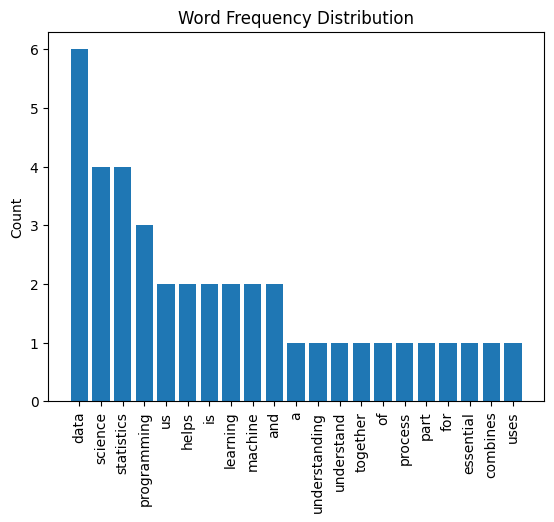

In [24]:
plt.figure()
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution")
plt.ylabel("Count")
plt.show()


### Student Practice

1. Pick your own longer paragraph (5+ sentences) and build the same word frequency table.
2. Compute the skewness of the word counts. Is it right-skewed (consistent with Zipf's Law)?
3. What percentage of words in your vocabulary appear only once? (This is usually a large percentage — that's Zipf's Law in action.)


In [25]:
# Write your answer here
import numpy as np
import pandas as pd

paragraph = (
    "Machine learning is an important part of data science. "
    "Data science uses statistics and programming to understand data. "
    "Machine learning helps computers learn patterns from data. "
    "Statistics helps us analyze data and make better decisions. "
    "Programming allows us to process large amounts of data efficiently. "
    "Data science combines programming, statistics, and machine learning."
)

# Tokenize words
tokens = paragraph.lower().replace('.', '').replace(',', '').split()

tokens_array = np.array(tokens)

# Create vocabulary and count words
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]

word_freq = pd.DataFrame({
    'word': vocabulary,
    'count': counts
}).sort_values('count', ascending=False).reset_index(drop=True)

print(word_freq)

# 2. Skewness
skewness = word_freq['count'].skew()
print("\nSkewness of word counts:", skewness)

# 3. Percentage of words appearing only once
once_count = np.sum(word_freq['count'] == 1)
total_words = len(word_freq)

percentage_once = (once_count / total_words) * 100

print("Percentage of words appearing only once:",
      f"{percentage_once:.2f}%")

           word  count
0          data      7
1    statistics      3
2   programming      3
3      learning      3
4       science      3
5       machine      3
6           and      3
7            to      2
8            us      2
9         helps      2
10           of      2
11   understand      1
12      process      1
13     patterns      1
14         part      1
15         make      1
16       allows      1
17        large      1
18        learn      1
19      amounts      1
20           is      1
21    important      1
22         from      1
23  efficiently      1
24    decisions      1
25    computers      1
26     combines      1
27       better      1
28      analyze      1
29           an      1
30         uses      1

Skewness of word counts: 2.6771626771640142
Percentage of words appearing only once: 64.52%


## Step 2: Correlation between sentence length and vocabulary diversity

### Demonstration


In [26]:
sentences = [
    "I like data science.",
    "Machine learning models require lots of clean labeled training data to perform well.",
    "Statistics matters.",
    "Understanding both statistics and programming together is essential for real data science work in industry.",
    "NumPy and pandas are useful tools for data analysis in Python."
]

sentence_stats = []
for s in sentences:
    toks = s.lower().replace('.', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = sentence_df['unique_words'] / sentence_df['length']
sentence_df


,sentence,length,unique_words,diversity_ratio
0,I like data science.,4,4,1.0
1,Machine learning models require lots of clean ...,13,13,1.0
2,Statistics matters.,2,2,1.0
3,Understanding both statistics and programming ...,15,15,1.0
4,NumPy and pandas are useful tools for data ana...,11,11,1.0


In [27]:
correlation = sentence_df['length'].corr(sentence_df['unique_words'])
print(f"Correlation between sentence length and unique word count: {correlation:.3f}")


Correlation between sentence length and unique word count: 1.000


### Student Practice

Write 5 sentences of your own, varying in length. Build the same table and compute the correlation between `length` and `unique_words`. Is the correlation strong? Does this match your intuition (longer sentences tend to have more unique words)?


In [28]:
# Write your answer here

sentences = [
    "I like Python.",
    "Python is useful for data analysis.",
    "Machine learning helps computers learn patterns from data.",
    "Data science combines statistics, programming, and machine learning to solve real-world problems.",
    "Learning programming and statistics together helps students understand data and build useful machine learning applications."
]

sentence_stats = []

for s in sentences:
    toks = s.lower().replace('.', '').replace(',', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = sentence_df['unique_words'] / sentence_df['length']

print(sentence_df)

correlation = sentence_df['length'].corr(sentence_df['unique_words'])
print(f"\nCorrelation: {correlation:.3f}")

                                            sentence  length  unique_words  \
0                                     I like Python.       3             3   
1                Python is useful for data analysis.       6             6   
2  Machine learning helps computers learn pattern...       8             8   
3  Data science combines statistics, programming,...      12            12   
4  Learning programming and statistics together h...      15            13   

   diversity_ratio  
0            1.000  
1            1.000  
2            1.000  
3            1.000  
4            0.867  

Correlation: 0.989


**Reflection:** Why might `diversity_ratio` (unique words / total words) be a more useful metric than raw `unique_words` count when comparing sentences of very different lengths?

*Your answer:*

diversity_ratio is more useful because it considers sentence length. A long sentence naturally has more unique words, so the ratio gives a fairer comparison of vocabulary diversity between sentences of different lengths.

# Final Self-Check

- [ ] I computed and correctly interpreted skewness (not just mean/std)
- [ ] I visualized a distribution and connected the shape to the skewness number
- [ ] I computed correlation and correctly judged strength (weak/moderate/strong)
- [ ] I ran a t-test and correctly interpreted the p-value (significant or not)
- [ ] I computed a confidence interval and can explain what it means in plain language
- [ ] I completed Mini Project A (image stats) or B (text distribution/correlation)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Why is it important to look at data visually (histograms, boxplots) and not just rely on summary numbers like mean and std?

2. If a t-test gives you p = 0.20, what should you conclude, and what should you NOT conclude? (Common misconception to address: "not significant" does not mean "definitely no difference.")

3. How does understanding your data's statistics (distribution shape, correlations) help you make better decisions in the next stage — building an ML model?

4. What's one statistics concept from this lab you still feel unsure about? Be specific.


## Final Reflection

1. Visualizations like histograms and boxplots help us see the distribution, skewness, spread, and outliers. Mean and standard deviation alone may hide these patterns.

2. If a t-test gives p = 0.20, the result is not statistically significant at the 0.05 level. We should not conclude that there is definitely no difference; it only means there is not enough evidence to claim a significant difference.

3. Understanding distributions and correlations helps us identify patterns, outliers, relationships, and possible problems in the data. This helps us choose suitable features and preprocessing methods for an ML model.

4. I am still slightly unsure about confidence intervals, especially how to interpret them correctly in plain language and what the 95% confidence level means.